#Anggota Kelompok:
Mila Lestari 			(2208107010002)

Zahra Zafira 			(2208107010040)

Pryta Rosela 			(2208107010046)

Cut Sula Fhatia Rahma 	(2208107010048)

Widya Nurul Sukma		 (2208107010054)

# **Tentang Dataset**

Dataset ini berisi data tentang prediksi kemungkinan penyakit jantung pada pasien, dengan 11 fitur yang dapat digunakan untuk memprediksi penyakit jantung. Fitur-fitur tersebut mencakup informasi seperti usia, jenis kelamin, jenis nyeri dada, tekanan darah, kolesterol, gula darah puasa, hasil EKG, detak jantung maksimum, angina yang disebabkan oleh olahraga, dan tingkat depresi ST. Dataset ini terdiri dari 918 observasi, yang berasal dari penggabungan lima dataset independen yang lebih kecil, dan digunakan untuk tujuan penelitian dan pengembangan model machine learning untuk deteksi dini penyakit jantung. Dataset ini sangat berguna untuk menganalisis faktor-faktor yang mempengaruhi risiko penyakit jantung pada pasien. Berikut Link Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data


# **Project Klasifikasi dengan Multiple Algorithms**

**Implementasi Algoritma Logistic Regression, K-NN, Naïve Bayes, dan Decision Tree**

**Tujuan Project:** Mengimplementasikan dan membandingkan performa berbagai algoritma klasifikasi menggunakan dataset nyata.

# **1. Persiapan Awal**

### **1.1 Import Libraries yang Dibutuhkan**

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_curve, roc_auc_score)

### **1.2 Load Dataset**

In [ ]:
# Connect ke Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets/heart.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Pemahaman Dataset**

### **2.1 Informasi dan Statistik Deskriptif**

In [ ]:
# Pemahaman awal data
print("Informasi Dataset:")
print(df.info())
print("\nStatistik Deskriptif:")
print(df.describe())

# Cek missing values
print("\nMissing Values:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Statistik Deskriptif:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.5108

### **2.2 Visualisasi Distribusi Target**

<ipython-input-10-b331db7146ab>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='Set2')


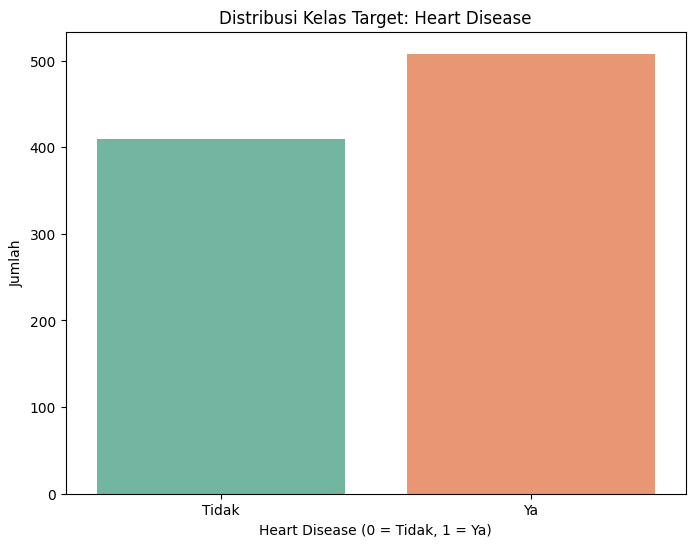

In [ ]:
# Visualisasi distribusi target
plt.figure(figsize=(8, 6))
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Distribusi Kelas Target: Heart Disease')
plt.xlabel('Heart Disease (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak', 'Ya'])
plt.show()

Keterangan:

- Dataset ini berisi **918 sampel**  
- Memiliki **11 fitur input** dan **1 fitur target** (`HeartDisease`)
- Target klasifikasi adalah **deteksi penyakit jantung**, dengan:
  - `0` = Tidak memiliki penyakit jantung  
  - `1` = Memiliki penyakit jantung
- Distribusi kelas menunjukkan **cukup seimbang**, yaitu:
  - Sekitar **55%** sampel diklasifikasikan memiliki penyakit jantung (`1`)
  - Sekitar **45%** sampel tidak memiliki penyakit jantung (`0`)


# **3. Eksplorasi Data & Pra-pemrosesan**

### **3.1 Analisis Korelasi**

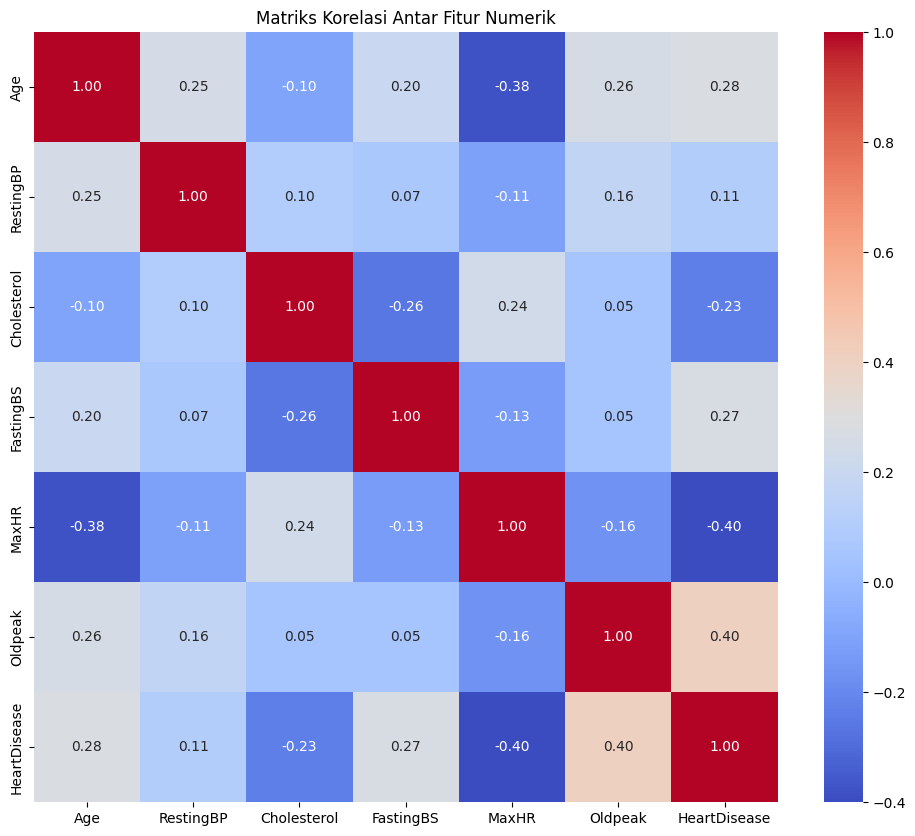

In [ ]:
# Ambil hanya kolom numerik
df_numerik = df.select_dtypes(include=['int64', 'float64'])

# Analisis korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df_numerik.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur Numerik')
plt.show()

In [ ]:
# Korelasi antara semua fitur numerik dengan target
correlation_with_target = df_numerik.corr()['HeartDisease'].sort_values(ascending=False)

print(correlation_with_target)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


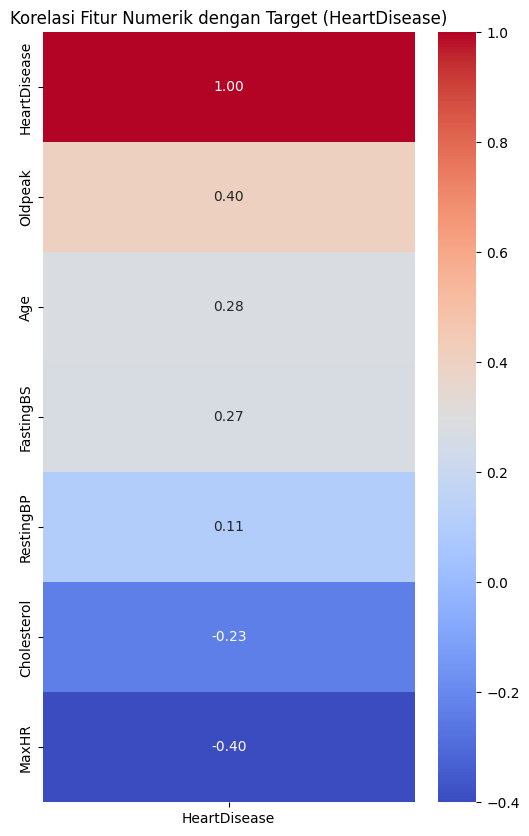

In [ ]:
plt.figure(figsize=(6, 10))
sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Numerik dengan Target (HeartDisease)')
plt.show()

### **3.2 Penanganan Missing Values**

Pada dataset tersebut tidak ada Missing Values

### **3.3 Pemisahan Fitur dan Target**

In [ ]:
# Pisahkan fitur dan target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

### **3.4 Encoding Data Kategorikal**

In [ ]:
# Daftar fitur kategorikal
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Lakukan label encoding pada setiap fitur kategorikal
le = LabelEncoder()
for feature in categorical_features:
    X[feature] = le.fit_transform(X[feature])

### **3.5 Standardisasi Data Numerik**

In [ ]:
# Standarisasi fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **3.6 Split Data Training dan Testing**

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

Keterangan:

* Data dibagi menjadi 80% training dan 20% testing
* Standardisasi dilakukan untuk menormalkan skala fitur numerik

# **4. Implementasi Model**

### **4.1 Model 1: Logistic Regression**

In [ ]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]  # untuk kurva ROC

### **4.2 Model 2: K-Nearest Neighbor**

##### **4.2.1 Pencarian Nilai K Optimal**

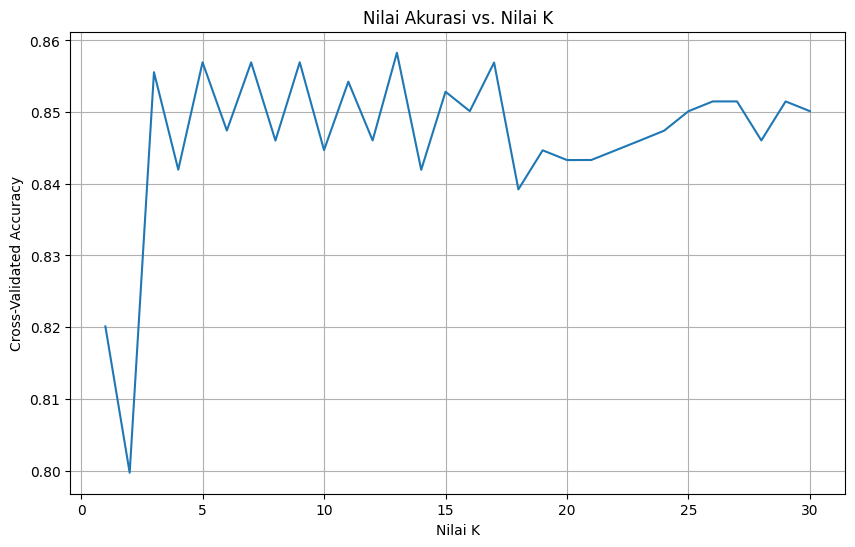

K optimal: 13


In [ ]:
# Mencari K optimal
k_range = range(1, 31)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Visualisasi pencarian K terbaik
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel('Nilai K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Nilai Akurasi vs. Nilai K')
plt.grid(True)
plt.show()

# Pilih K optimal
optimal_k = k_scores.index(max(k_scores)) + 1
print(f"K optimal: {optimal_k}")

##### **4.2.2 Implementasi KNN dengan K Optimal**

In [ ]:
# Terapkan model KNN dengan K optimal
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # untuk kurva ROC

### **4.3 Model 3: Naive Bayes**

In [ ]:
# Model 3: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # untuk kurva ROC

### **4.4 Model 4: Decision Tree**

In [ ]:
# Model 4: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]  # untuk kurva ROC

Keterangan:

* Logistic Regression menggunakan max_iter=1000 untuk memastikan konvergensi
* KNN menggunakan nilai K optimal = 13
* Naive Bayes menggunakan asumsi distribusi Gaussian untuk fitur
* Decision Tree menggunakan parameter default dengan random_state=42

# **5. Evaluasi Model**

### **5.1 Function untuk Evaluasi**

In [ ]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} Evaluation ---")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    print(classification_report(y_true, y_pred))

    # ROC Curve
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

    # Calculate Log-Loss
    logloss = log_loss(y_true, y_prob)

    # Return metrics
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted'),
        'f1': f1_score(y_true, y_pred, average='weighted'),
        'log_loss': logloss
    }


### **5.2 Evaluasi dan Perbandingan Model**


--- Logistic Regression Evaluation ---


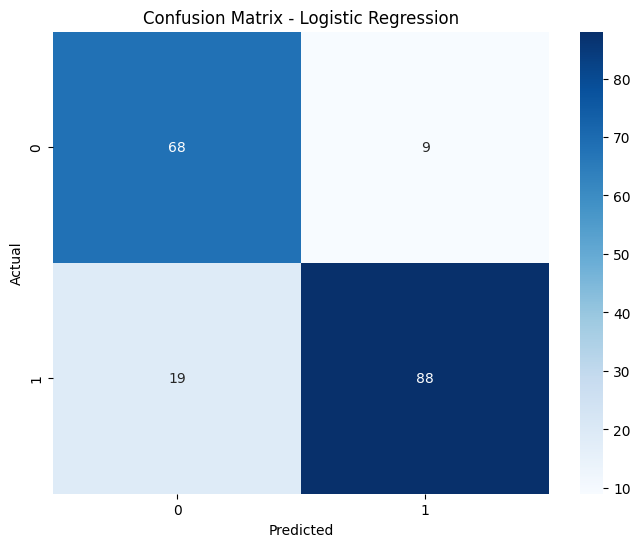

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



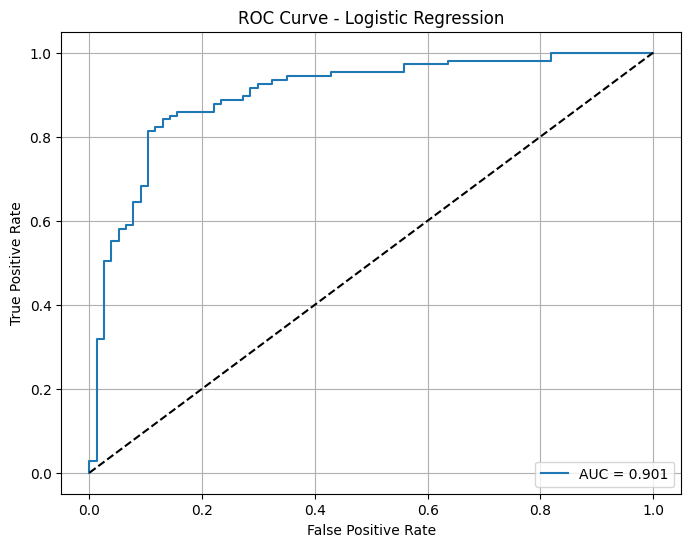


--- K-Nearest Neighbor Evaluation ---


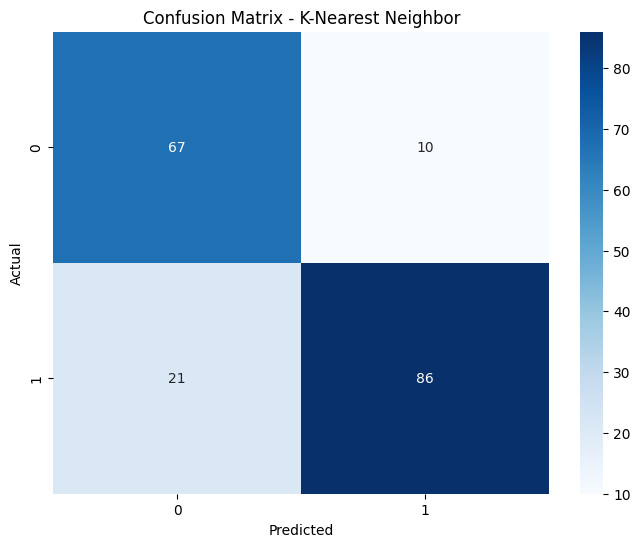

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        77
           1       0.90      0.80      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184



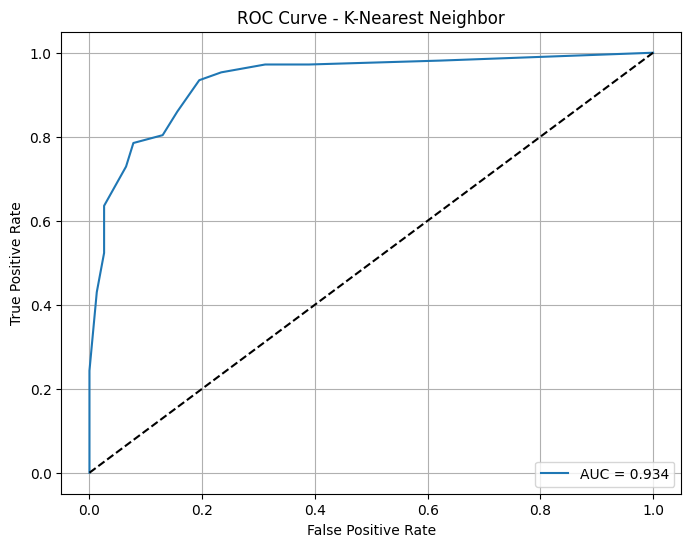


--- Naive Bayes Evaluation ---


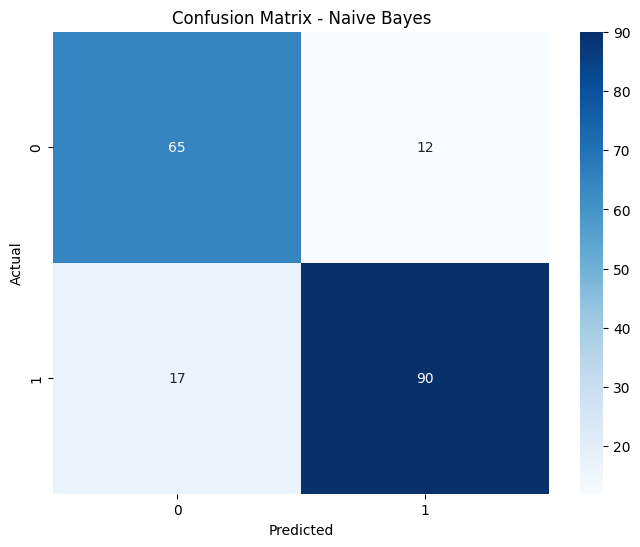

              precision    recall  f1-score   support

           0       0.79      0.84      0.82        77
           1       0.88      0.84      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



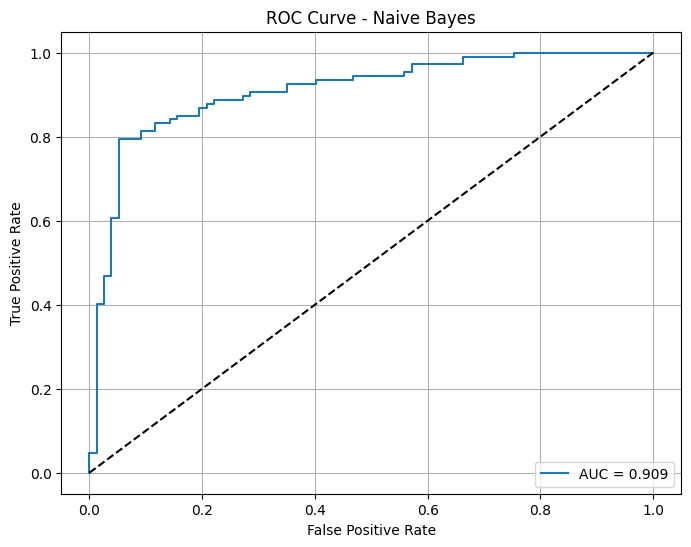


--- Decision Tree Evaluation ---


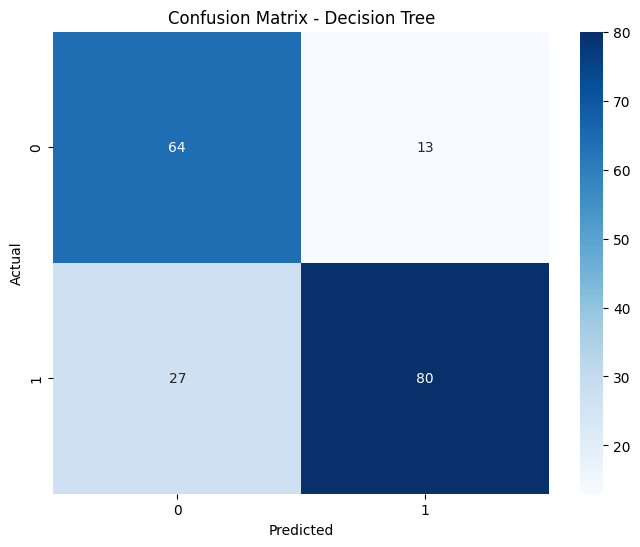

              precision    recall  f1-score   support

           0       0.70      0.83      0.76        77
           1       0.86      0.75      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184



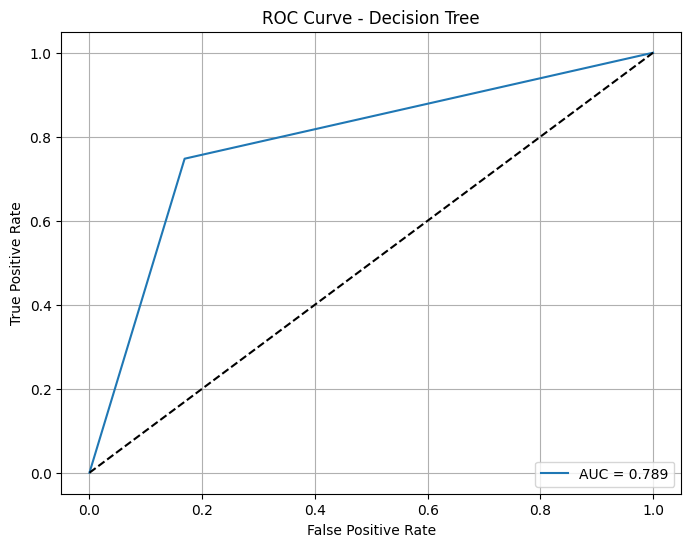

In [ ]:
from sklearn.metrics import log_loss
# Evaluasi setiap model
lr_metrics = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
knn_metrics = evaluate_model(y_test, y_pred_knn, y_prob_knn, "K-Nearest Neighbor")
nb_metrics = evaluate_model(y_test, y_pred_nb, y_prob_nb, "Naive Bayes")
dt_metrics = evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")

In [ ]:
results = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'K-Nearest Neighbor': knn_metrics,
    'Naive Bayes': nb_metrics,
    'Decision Tree': dt_metrics
})

print("\nPerbandingan Kinerja Model:")
print(results.T)  # transpose



Perbandingan Kinerja Model:
                     accuracy  precision    recall        f1  log_loss
Logistic Regression  0.847826   0.854653  0.847826  0.848736  0.408306
K-Nearest Neighbor   0.831522   0.839561  0.831522  0.832573  0.686466
Naive Bayes          0.842391   0.844828  0.842391  0.842984  0.568207
Decision Tree        0.782609   0.794548  0.782609  0.784058  7.835577


Keterangan:

* Untuk setiap model, kita mengevaluasi menggunakan:

 * Confusion Matrix: Menunjukkan jumlah prediksi benar dan salah untuk setiap kelas
 * Classification Report: Precision, Recall, F1-Score untuk setiap kelas
 * ROC Curve dan AUC Score (untuk klasifikasi biner)
 * Log-Loss: Mengukur seberapa baik probabilitas prediksi model mendekati label sebenarnya

# **6. Analisis Hasil**

### **6.1 Perbandingan Performa Model**

In [ ]:
# Perbandingan performance model
models = ['Logistic Regression', 'KNN', 'Naive Bayes', 'Decision Tree']
metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [lr_metrics['accuracy'], knn_metrics['accuracy'],
                nb_metrics['accuracy'], dt_metrics['accuracy']],
    'Precision': [lr_metrics['precision'], knn_metrics['precision'],
                nb_metrics['precision'], dt_metrics['precision']],
    'Recall': [lr_metrics['recall'], knn_metrics['recall'],
              nb_metrics['recall'], dt_metrics['recall']],
    'F1 Score': [lr_metrics['f1'], knn_metrics['f1'],
                nb_metrics['f1'], dt_metrics['f1']]
})

print("\nPerbandingan Performa Model:")
print(metrics_df)


Perbandingan Performa Model:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.847826   0.854653  0.847826  0.848736
1                  KNN  0.831522   0.839561  0.831522  0.832573
2          Naive Bayes  0.842391   0.844828  0.842391  0.842984
3        Decision Tree  0.782609   0.794548  0.782609  0.784058


### **6.2 Visualisasi Perbandingan Model**

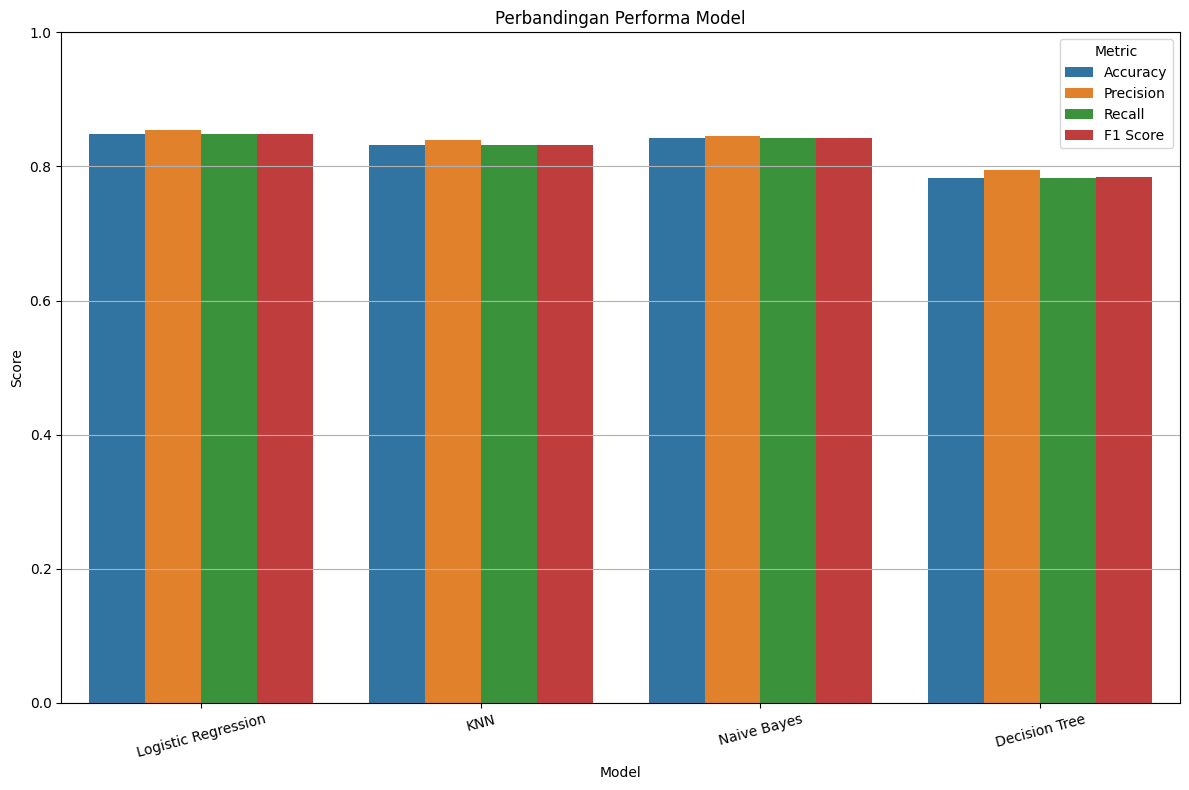

In [ ]:
# Visualisasi perbandingan model
plt.figure(figsize=(12, 8))
metrics_long = pd.melt(metrics_df, id_vars=['Model'],
                       value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                       var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_long)
plt.title('Perbandingan Performa Model')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### **6.3 Visualisasi Decision Tree**

In [ ]:
# Visualisasi Decision Tree (jika tidak terlalu kompleks)
plt.figure(figsize=(300, 100))
plot_tree(dt_model, filled=True, feature_names=X.columns,
         class_names=[str(c) for c in np.unique(y)], rounded=True)
plt.title('Visualisasi Decision Tree')
plt.show()

### **6.4 Analisis Feature Importance (Decision Tree)**

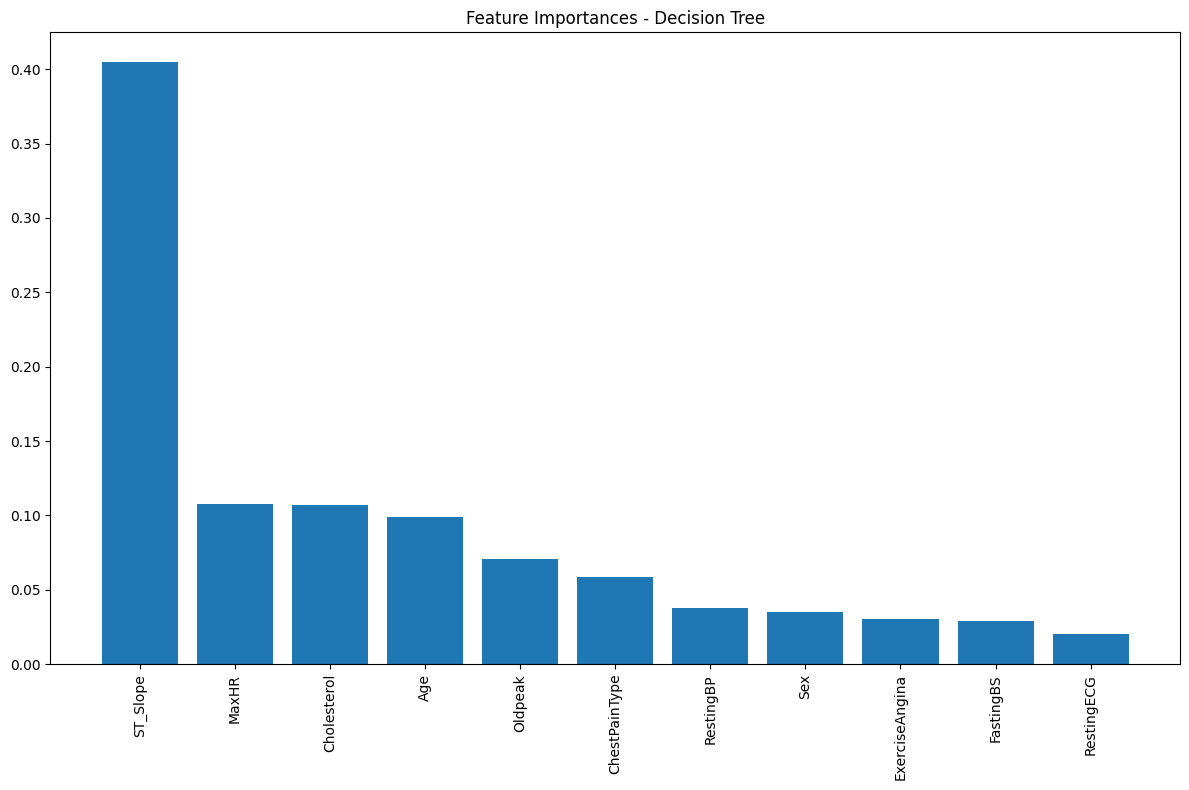

In [ ]:
# Feature Importance untuk Decision Tree
if hasattr(dt_model, 'feature_importances_'):
    importances = dt_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 8))
    plt.bar(range(X.shape[1]), importances[indices])
    plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
    plt.title('Feature Importances - Decision Tree')
    plt.tight_layout()
    plt.show()

### **6.5 Analisis Koefisien (Logistic Regression)**

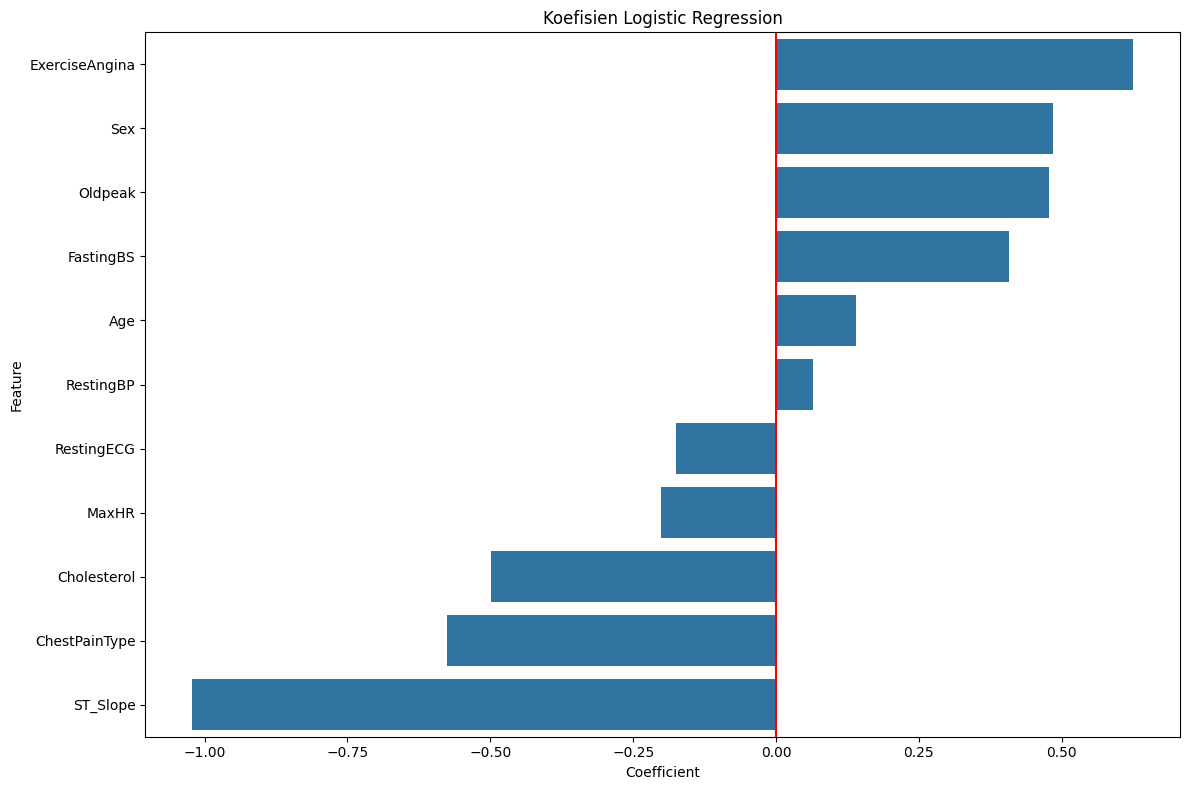

In [ ]:
# Koefisien Logistic Regression untuk interpretasi (jika klasifikasi biner)
if hasattr(lr_model, 'coef_'):
    coef = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lr_model.coef_[0]
    }).sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coef)
    plt.title('Koefisien Logistic Regression')
    plt.axvline(x=0, color='r', linestyle='-')
    plt.tight_layout()
    plt.show()

Keterangan:

* Visualisasi perbandingan model membantu melihat kinerja relatif setiap algoritma
* Feature importance mengidentifikasi fitur-fitur yang paling berpengaruh dalam prediksi
* Koefisien Logistic Regression menunjukkan arah dan kekuatan hubungan antara fitur dan target

# 7. **Kesimpulan dan Rekomendasi**

In [ ]:
# Rangkuman performa model
best_model = metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Model']
print(f"\nModel terbaik berdasarkan akurasi: {best_model}")
print("\nRangkuman hasil:")
for model in models:
    idx = metrics_df[metrics_df['Model'] == model].index[0]
    acc = metrics_df.loc[idx, 'Accuracy']
    print(f"- {model}: {acc:.4f}")


Model terbaik berdasarkan akurasi: Logistic Regression

Rangkuman hasil:
- Logistic Regression: 0.8478
- KNN: 0.8315
- Naive Bayes: 0.8424
- Decision Tree: 0.7826


### **7.1 Rangkuman Hasil**

Dari hasil eksperimen dengan empat algoritma klasifikasi yang berbeda, dapat diambil beberapa kesimpulan:

1. Logistic Regression mencapai akurasi tertinggi (84,78%) dan menunjukkan kinerja terbaik secara keseluruhan untuk semua metrik.
2. Naïve Bayes memberikan kinerja kedua terbaik dengan akurasi 84,23%.
3. KNN dengan K optimal=13 menunjukkan kinerja yang baik dengan akurasi 83,15%.
4. Decision Tree memiliki akurasi terendah yaitu 78,26%, menunjukkan kemungkinan masalah overfitting.
5. Fitur yang paling berpengaruh dalam prediksi adalah ST_Slope